In [ ]:
import subprocess
import os
import re
import zipfile
import json
from tqdm import tqdm
import shutil

import src.evaluate_model as eval
import src.preprocessing as prep
import src.hyperfuse_model as hf_model

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

#### Download data from server

In [ ]:
local_path = "data/mri_nifti_data/"
os.makedirs(local_path, exist_ok=True)

# Check how many files we currently have
existing_files = [f for f in os.listdir(local_path)]

print(f"Currently have {len(existing_files)} files in the local directory.")

# If we already have our 200 files, we can skip the entire download process
if len(existing_files) >= 200:
    print(f"All {len(existing_files)} files are already downloaded. Skipping AWS execution.")
else:
    print("Starting master download process...")
    
    # 1. Inject credentials for the Mixed Protocol dataset
    my_env = os.environ.copy()
    my_env["AWS_ACCESS_KEY_ID"] = "REDACTED"
    my_env["AWS_SECRET_ACCESS_KEY"] = "REDACTED"

    # 2. Fetch the absolute ground truth list of NIFTI files from the server
    print("Fetching master list of available NIFTI files from AWS...")
    s3_base_path = "s3://naccmri-quickaccess-sub/investigator/MRI/within1yr/nifti/"
    command_ls = ["aws", "s3", "ls", s3_base_path]
    result_ls = subprocess.run(command_ls, env=my_env, capture_output=True, text=True)

    if result_ls.returncode != 0:
        print("Error fetching list from AWS:", result_ls.stderr)
    else:
        # Extract all the NACC IDs from the server output using a regular expression
        available_ids = set(re.findall(r'NACC\d+', result_ls.stdout))
        
        # Load the tabular clinical data
        clinical_df = pd.read_csv('data/investigator_nacc72.csv', low_memory=False)
        mri_df = pd.read_csv('data/investigator_mri_nacc72.csv', low_memory=False)

        # Find common patient IDs
        common_ids = set(clinical_df['NACCID']).intersection(set(mri_df['NACCID']))
        print(f"Total overlapping patients {len(common_ids)}")

        guaranteed_df = clinical_df[clinical_df['NACCID'].isin(common_ids) & clinical_df['NACCID'].isin(available_ids)]

        # Drop duplicate visits, keeping only the most recent visit to get the most definitive diagnosis
        guaranteed_df = guaranteed_df.sort_values('VISITYR', ascending=False).drop_duplicates(subset=['NACCID'])

        # Define our strict exclusion masks to prevent comorbidities
        # We want to ensure a patient only has a 1 in their specific disease column
        disease_cols = ['NACCALZD', 'NACCVASC', 'NACCLBDE', 'NACCFTD']
        has_any_disease = guaranteed_df[disease_cols].sum(axis=1)

        # 1. Cognitively Normal (CN) - Label 0
        # Must be normal and strictly NOT diagnosed with any of the four diseases
        cn_mask = (guaranteed_df['NORMCOG'] == 1) & \
                  (guaranteed_df['NACCALZD'] != 1) & \
                  (guaranteed_df['NACCVASC'] != 1) & \
                  (guaranteed_df['NACCLBDE'] != 1) & \
                  (guaranteed_df['NACCFTD'] != 1)
                  
        cn_df = guaranteed_df[cn_mask].copy()
        cn_df['DIAGNOSIS_LABEL'] = 0
        
        # 2. Mild Cognitive Impairment (MCI) - Label 1
        # Updated to 3 based on NACC UDS data dictionary
        mci_mask = (guaranteed_df['NACCUDSD'] == 3) & \
                   (guaranteed_df['NACCALZD'] != 1) & \
                   (guaranteed_df['NACCVASC'] != 1) & \
                   (guaranteed_df['NACCLBDE'] != 1) & \
                   (guaranteed_df['NACCFTD'] != 1)
                   
        mci_df = guaranteed_df[mci_mask].copy()
        mci_df['DIAGNOSIS_LABEL'] = 1
        
        # 3. Alzheimer disease (AD) - Label 2
        # Must explicitly have AD and strictly NOT have the other three
        ad_mask = (guaranteed_df['NACCALZD'] == 1) & \
                  (guaranteed_df['NACCVASC'] != 1) & \
                  (guaranteed_df['NACCLBDE'] != 1) & \
                  (guaranteed_df['NACCFTD'] != 1)
                  
        ad_df = guaranteed_df[ad_mask].copy()
        ad_df['DIAGNOSIS_LABEL'] = 2
        
        # 4. Vascular Dementia (VaD) - Label 3
        vad_mask = (guaranteed_df['NACCVASC'] == 1) & \
                   (guaranteed_df['NACCALZD'] != 1) & \
                   (guaranteed_df['NACCLBDE'] != 1) & \
                   (guaranteed_df['NACCFTD'] != 1)
                   
        vad_df = guaranteed_df[vad_mask].copy()
        vad_df['DIAGNOSIS_LABEL'] = 3
        
        # 5. Lewy Body Dementia (LBD) - Label 4
        lbd_mask = (guaranteed_df['NACCLBDE'] == 1) & \
                   (guaranteed_df['NACCALZD'] != 1) & \
                   (guaranteed_df['NACCVASC'] != 1) & \
                   (guaranteed_df['NACCFTD'] != 1)
                   
        lbd_df = guaranteed_df[lbd_mask].copy()
        lbd_df['DIAGNOSIS_LABEL'] = 4
        
        # 6. Frontotemporal Dementia (FTD) - Label 5
        ftd_mask = (guaranteed_df['NACCFTD'] == 1) & \
                   (guaranteed_df['NACCALZD'] != 1) & \
                   (guaranteed_df['NACCVASC'] != 1) & \
                   (guaranteed_df['NACCLBDE'] != 1)
                   
        ftd_df = guaranteed_df[ftd_mask].copy()
        ftd_df['DIAGNOSIS_LABEL'] = 5

        print(f"Available pure CN: {len(cn_df)}")
        print(f"Available pure MCI: {len(mci_df)}")
        print(f"Available pure AD: {len(ad_df)}")
        print(f"Available pure VaD: {len(vad_df)}")
        print(f"Available pure LBD: {len(lbd_df)}")
        print(f"Available pure FTD: {len(ftd_df)}")

        # Standardize the cohort size based on the smallest available class to ensure perfect balance
        min_class_size = min(len(cn_df), len(mci_df), len(ad_df), len(vad_df), len(lbd_df), len(ftd_df))

        final_cohort_df = pd.concat([
            cn_df.sample(n=min_class_size, random_state=42),
            mci_df.sample(n=min_class_size, random_state=42),
            ad_df.sample(n=min_class_size, random_state=42),
            vad_df.sample(n=min_class_size, random_state=42),
            lbd_df.sample(n=min_class_size, random_state=42),
            ftd_df.sample(n=min_class_size, random_state=42)
        ])

        final_ids = final_cohort_df['NACCID'].tolist()

        # Check your extracted folders against your new master list
        for folder_name in os.listdir(local_path):
            folder_path = os.path.join(local_path, folder_name)

            # If the folder is not in your new finalized cohort, delete it
            if os.path.isdir(folder_path) and folder_name not in final_ids:
                print(f"Removing unused patient data {folder_name}")
                shutil.rmtree(folder_path)

        # 5. Download the files
        print("Downloading files...")
        
        # Wrap the loop with tqdm to create the progress bar
        progress_bar = tqdm(final_ids, desc="Downloading NIFTI files")
        
        for pid in progress_bar:
            # Only download the file if it does not already exist in the folder
            if not any(pid in f for f in existing_files):
                
                # Update the extra information space next to the loading bar
                progress_bar.set_postfix(current_patient=pid)
                
                command_cp = [
                    "aws", "s3", "cp", s3_base_path, local_path,
                    "--recursive", "--exclude", "*", "--include", f"*{pid}*"
                ]
                subprocess.run(command_cp, env=my_env, capture_output=True)
                
        print("Master download complete. You have exactly 200 guaranteed files.")

Currently have 228 files in the local directory.
All 228 files are already downloaded. Skipping AWS execution.


In [3]:
zip_files = [f for f in os.listdir(local_path) if f.endswith('.zip')]

print(f"Found {len(zip_files)} zip files. Starting extraction...")

progress_bar = tqdm(zip_files, desc="Unzipping NIFTI files")

for zip_name in progress_bar:
    # Extract the patient ID from the filename
    match = re.search(r'(NACC\d+)', zip_name)
    if match:
        # Update the extra information space next to the loading bar
        progress_bar.set_postfix(current_file=zip_name)

        patient_id = match.group(1)
        
        # Create a dedicated folder for this specific patient
        extract_dir = os.path.join(local_path, patient_id)
        os.makedirs(extract_dir, exist_ok=True)
        
        zip_path = os.path.join(local_path, zip_name)
        
        # Extract the contents into the new folder
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)
            
        # Delete the raw zip archive to keep the directory clean and save space
        os.remove(zip_path)

print("Extraction complete. Raw zip files have been removed.")

Found 0 zip files. Starting extraction...


Unzipping NIFTI files: 0it [00:00, ?it/s]

Extraction complete. Raw zip files have been removed.


### Preprocess Data

In [2]:
# Read only the header row
df_headers = pd.read_csv('data/investigator_nacc72.csv', nrows=0, low_memory=False)
all_columns = df_headers.columns.tolist()

# Define the keywords we are looking for
keywords = [
    'AGE', 'SEX', 'EDUC', 'APOE', 'FAM', 'BMI', 'HYPER', 
    'DIAB', 'FIB', 'STROKE', 'TIA', 'DEP', 'HALLUC', 
    'ALC', 'TOBAC', 'SMOK', 'TBI', 'PARK', 'SLEEP', 
    'THYROID', 'SEIZ', 'HEAR', 'VIS'
]

print("Matching Column Headers:")

# Loop through all the columns and print the ones that contain our keywords
for col in all_columns:
    for key in keywords:
        if key in col.upper():
            print(col)
            break

Matching Column Headers:
VISITMO
VISITDAY
VISITYR
SEX
EDUC
INDEPEND
INSEX
INEDUC
INVISITS
NACCFAM
TOBAC30
TOBAC100
SMOKYRS
QUITSMOK
ALCOCCAS
ALCFREQ
CVAFIB
CBSTROKE
CBTIA
TIAMULT
SEIZURES
NACCTBI
TBI
TBIBRIEF
TBIEXTEN
TBIWOLOS
TBIYEAR
DIABETES
DIABTYPE
HYPERTEN
HYPERCHO
THYROID
OTHSLEEP
ALCOHOL
DEP2YRS
DEPOTHR
VISION
VISCORR
VISWCORR
HEARING
HEARAID
HEARWAID
HXHYPER
HXSTROKE
DEPD
DEPDSEV
PARKSIGN
PARKGAIT
CORTVISL
CORTVISR
COGVIS
DECAGE
BEDEP
BEAGE
MOMOPARK
PARKAGE
ALSAGE
MOAGE
MMSEVIS
MMSEHEAR
MOCAVIS
MOCAHEAR
RESPHEAR
IMAGEWMH
PARK
STROKE
DEP
DEPIF
DEPTREAT
ALCDEM
ALCDEMIF
ALCABUSE
DIABET
AFIBRILL
HYPERT
SLEEPAP
SLEEPOTH
SLEEPOTX
NACCAGEB
NACCAGE
NACCADEP
NACCBMI
NGDSEXOM
NGDSEXAC
NACCAPOE
NPSEX
NACCDAGE


In [3]:
local_path = "data/mri_nifti_data/"
downloaded_pids = [f for f in os.listdir(local_path) if os.path.isdir(os.path.join(local_path, f))]

clinical_df = pd.read_csv('data/investigator_nacc72.csv', low_memory=False)

# Grab the most recent visit for all downloaded patients to get the definitive diagnosis
guaranteed_df = clinical_df[clinical_df['NACCID'].isin(downloaded_pids)].sort_values('VISITYR', ascending=False).drop_duplicates(subset=['NACCID'])

final_ids = []
labels = []
clinical_tensors = []

for index, row in guaranteed_df.iterrows():
    # Figure out exactly which disease class they belong to
    has_ad = row['NACCALZD'] == 1
    has_vad = row['NACCVASC'] == 1
    has_lbd = row['NACCLBDE'] == 1
    has_ftd = row['NACCFTD'] == 1
    is_normal = row['NORMCOG'] == 1
    is_mci = row['NACCUDSD'] == 3
    
    disease_sum = int(has_ad) + int(has_vad) + int(has_lbd) + int(has_ftd)
    
    label = -1
    if is_normal and disease_sum == 0: label = 0
    elif is_mci and disease_sum == 0: label = 1
    elif has_ad and disease_sum == 1: label = 2
    elif has_vad and disease_sum == 1: label = 3
    elif has_lbd and disease_sum == 1: label = 4
    elif has_ftd and disease_sum == 1: label = 5
    
    # If they perfectly match a pure class we add them to the PyTorch dataset
    if label != -1:
        final_ids.append(row['NACCID'])
        labels.append(label)
        
        # Extract the 23 features
        patient_features = [
            row.get('NACCAGE', 0), row.get('SEX', 1), row.get('EDUC', 0), 
            row.get('NACCAPOE', 0), row.get('NACCFAM', 0), row.get('NACCBMI', 25.0), 
            row.get('HYPERTEN', 0), row.get('HYPERCHO', 0), row.get('DIABETES', 0), 
            row.get('CVAFIB', 0), row.get('CBSTROKE', 0), row.get('CBTIA', 0), 
            row.get('DEP2YRS', 0), row.get('ALCOHOL', 0), row.get('TOBAC30', 0), 
            row.get('NACCTBI', 0), row.get('PARKSIGN', 0), row.get('SLEEPAP', 0), 
            row.get('THYROID', 0), row.get('SEIZURES', 0), row.get('HEARING', 0), 
            row.get('VISION', 0), row.get('INDEPEND', 1)
        ]
        
        # We append the raw list of numbers, not a tensor yet
        clinical_tensors.append(patient_features)

# After the loop finishes, mathematically normalize the entire batch of 23 features at once
scaler = StandardScaler()
normalized_clinical_data = scaler.fit_transform(clinical_tensors)

# Convert the normalized array into a list of individual PyTorch tensors
clinical_tensors = [torch.tensor(patient, dtype=torch.float32) for patient in normalized_clinical_data]

print(f"Successfully processed 23 features and labels for {len(clinical_tensors)} patients.")

Successfully processed 23 features and labels for 228 patients.


In [ ]:
# First split separates out the 20 percent testing set
# The remaining 80 percent becomes a temporary pool for training and validation
train_val_ids, test_ids, train_val_labels, test_labels, train_val_clin, test_clin = train_test_split(
    final_ids, labels, clinical_tensors, test_size=0.2, stratify=labels, random_state=42
)

# Second split divides the remaining 80 percent pool
# We want 10 percent of the total data for validation
# 10 is exactly 12.5 percent of 80 so we use a test_size of 0.125
train_ids, val_ids, train_labels, val_labels, train_clin, val_clin = train_test_split(
    train_val_ids, train_val_labels, train_val_clin, test_size=0.125, stratify=train_val_labels, random_state=42
)

print(f"Training patients {len(train_ids)}")
print(f"Validation patients {len(val_ids)}")
print(f"Testing patients {len(test_ids)}")

# Calculate the maximums ONLY using the training patients
max_mag = 0.0
max_slice = 0.0
max_te = 0.0
local_path = "data/mri_nifti_data/"

for pid in train_ids:
    patient_dir = os.path.join(local_path, pid)
    for root, dirs, files in os.walk(patient_dir):
        for file in files:
            if file.endswith('.json'):
                json_path = os.path.join(root, file)
                with open(json_path, 'r') as f:
                    meta = json.load(f)
                    
                mag = meta.get("MagneticFieldStrength", 0.0)
                slice_val = meta.get("SliceThickness", 0.0)
                te = meta.get("EchoTime", 0.0)
                
                if mag > max_mag: max_mag = mag
                if slice_val > max_slice: max_slice = slice_val
                if te > max_te: max_te = te

# Package the dynamically found training maximums
max_vals = {"mag": max_mag, "slice": max_slice, "te": max_te}
print(f"Dynamic Training Maxes: {max_vals}")

# Initialize the datasets using our safe maximums
train_dataset = prep.HyperFuseDataset(
    patient_ids=train_ids, 
    labels=train_labels, 
    clinical_features=train_clin, 
    max_vals=max_vals
)

# Initialize the datasets using our safe maximums
validation_dataset = prep.HyperFuseDataset(
    patient_ids=val_ids, 
    labels=val_labels, 
    clinical_features=val_clin, 
    max_vals=max_vals
)

test_dataset = prep.HyperFuseDataset(
    patient_ids=test_ids, 
    labels=test_labels, 
    clinical_features=test_clin, 
    max_vals=max_vals
)

# Wrap the datasets in DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(validation_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("DataLoaders are ready.")

Training patients 159
Validation patients 23
Testing patients 46
Dynamic Training Maxes: {'mag': 15000, 'slice': 16, 'te': 0.564}
DataLoaders are ready.


/home/abrah/miniconda3/envs/hyperfuse/lib/python3.10/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


In [5]:
# Disable this block after confirming the data pipeline is working correctly
if False: 
    # Test the data pipeline by pulling a single batch
    for images, meta_tokens, clin_tensors, batch_labels in train_loader:
        print("Image batch shape:", images.shape)
        print("Metadata batch shape:", meta_tokens.shape)
        print("Clinical batch shape:", clin_tensors.shape)
        print("Labels batch shape:", batch_labels.shape)

        # We use break to stop the loop after exactly one batch
        break

### Train Model

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the model
model = hf_model.HyperFuseNet(num_layers=3, num_classes=6, num_features=23, hidden_dim=256, base_channels=16).to(device)

# Standard optimizer for the visual feature extractor
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# CrossEntropyLoss automatically handles raw logits and applies Softmax
criterion = torch.nn.CrossEntropyLoss()

# Create a folder to hold model backups
os.makedirs("checkpoints", exist_ok=True)

epochs = 20
print("Starting End-to-End Hypergraph Training...")

epoch_loop = tqdm(range(epochs), desc="Training Progress")

for epoch in epoch_loop:
    model.train()
    
    for images, meta, clin, labels in train_loader:
        images = images.to(device)
        clin = clin.to(device)
        labels = labels.to(device, dtype=torch.long)
        
        optimizer.zero_grad()
        
        # The model outputs a single tensor of raw logits
        logits = model(images, clin)
        
        # Feed the logits directly to the loss function
        loss = criterion(logits, labels)
        
        loss.backward()
        optimizer.step()
        
    # Validation Phase
    model.eval()
    
    total_val_loss = 0
    total_correct = 0
    total_samples = 0
    
    with torch.no_grad():
        for val_images, val_meta, val_clin, val_labels in val_loader:
            val_images = val_images.to(device)
            val_clin = val_clin.to(device)
            val_labels = val_labels.to(device, dtype=torch.long)
            
            # Grab the raw logits
            val_logits = model(val_images, val_clin)
            batch_loss = criterion(val_logits, val_labels)
            
            # Multiply the mean loss by the batch size to get the total loss sum
            total_val_loss += batch_loss.item() * len(val_labels)
            
            # Argmax works the exact same way on logits as it does on percentages
            val_preds_classes = torch.argmax(val_logits, dim=1)
            total_correct += (val_preds_classes == val_labels).sum().item()
            total_samples += len(val_labels)
            
    # Calculate the true averages across the entire validation dataset
    val_loss = total_val_loss / total_samples
    val_acc = total_correct / total_samples

    # Save the current state of the model to disk
    torch.save(model.state_dict(), f"checkpoints/hyperfuse_epoch_{epoch+1}.pt")

    # Update the loading bar text with the live metrics
    epoch_loop.set_postfix(
        Train_Loss=f"{loss.item():.4f}", 
        Val_Loss=f"{val_loss:.4f}",
        Val_Acc=f"{val_acc:.4f}"
    )

Starting End-to-End Hypergraph Training...


Training Progress: 100%|██████████| 20/20 [36:24<00:00, 109.22s/it, Train_Loss=1.3797, Val_Acc=0.3913, Val_Loss=1.9237]


### Evaluate Model

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Rebuild the empty architecture with the exact same dimensions used in training
model = hf_model.HyperFuseNet(num_layers=3, num_classes=6, num_features=23, hidden_dim=256, base_channels=16).to(device)
# Re-initialize the loss function so the evaluation loop can calculate the validation loss
criterion = torch.nn.CrossEntropyLoss()

In [13]:
best_epoch = 1
best_f1 = 0.0
best_acc = 0.0

print("Hunting for the peak test Macro-F1 score...")

# Loop through all 20 saved checkpoints
for epoch in tqdm(range(1, 21), desc="Evaluating Epochs"):
    model.load_state_dict(torch.load(f"checkpoints/hyperfuse_epoch_{epoch}.pt"))
    model.eval()

    all_soft_probs = []
    all_true_labels = []

    with torch.no_grad():
        for test_images, test_meta, test_clin, test_labels in test_loader:
            test_images = test_images.to(device)
            test_clin = test_clin.to(device)
            
            # 1. Get raw logits from the updated model
            logits = model(test_images, test_clin)
            
            # 2. Convert logits to soft probabilities (0.0 to 1.0)
            probs = torch.softmax(logits, dim=1)
            
            all_soft_probs.append(probs.cpu().numpy())
            all_true_labels.append(test_labels.numpy())

    # Concatenate list of arrays into single numpy arrays
    probs_array = np.concatenate(all_soft_probs, axis=0)
    labels_array = np.concatenate(all_true_labels, axis=0)
    
    # 3. Get the hard predictions (index of the highest probability)
    top1_preds = np.argmax(probs_array, axis=1)
    
    # 4. Calculate metrics
    current_f1 = f1_score(labels_array, top1_preds, average='macro')
    current_acc = accuracy_score(labels_array, top1_preds)

    # Save the epoch if it is the new high score for F1
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_acc = current_acc
        best_epoch = epoch

print(f"\nPeak Results (Found at Epoch {best_epoch}):")
print(f"Macro-F1: {best_f1:.4f}")
print(f"Accuracy: {best_acc:.2%}")

Hunting for the peak test Macro-F1 score...


Evaluating Epochs: 100%|██████████| 20/20 [09:44<00:00, 29.24s/it]


Peak Results (Found at Epoch 13):
Macro-F1: 0.3122
Accuracy: 34.78%


Generating final evaluation for Epoch 13...


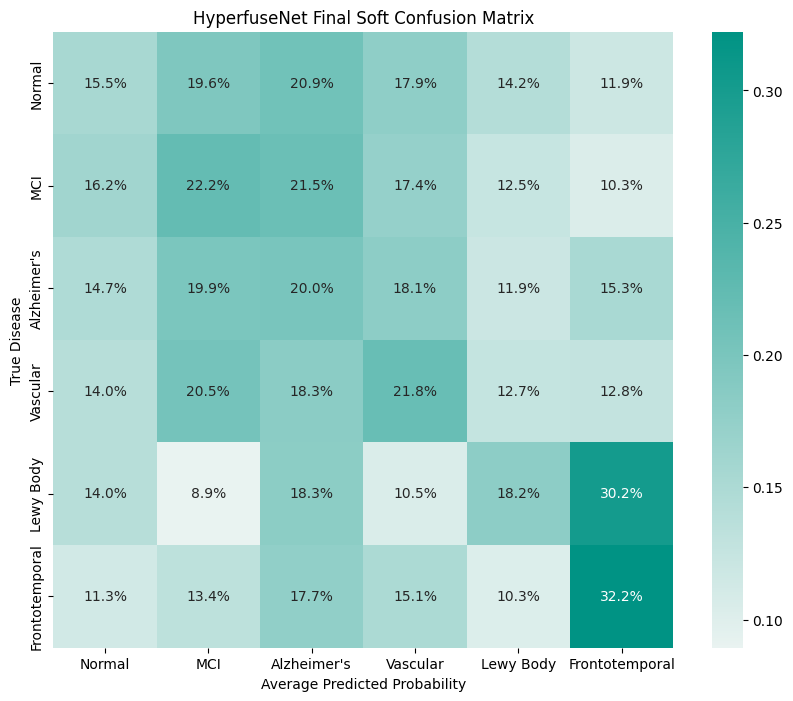

In [6]:
# If we already know it...
best_epoch = 13

print(f"Generating final evaluation for Epoch {best_epoch}...")

# Load the winning weights
model.load_state_dict(torch.load(f"checkpoints/hyperfuse_epoch_{best_epoch}.pt"))
model.eval()

best_soft_probs = []
best_true_labels = []

with torch.no_grad():
    for test_images, test_meta, test_clin, test_labels in test_loader:
        test_images = test_images.to(device)
        test_clin = test_clin.to(device)
        
        logits = model(test_images, test_clin)

        # Convert logits to soft probabilities
        probs = torch.softmax(logits, dim=1)
        
        best_soft_probs.extend(probs.cpu().numpy())
        best_true_labels.extend(test_labels.numpy())

disease_names = ["Normal", "MCI", "Alzheimer's", "Vascular", "Lewy Body", "Frontotemporal"]

eval.plot_soft_confusion_matrix(best_true_labels, best_soft_probs, disease_names, title="HyperfuseNet Final Soft Confusion Matrix")